<a href="https://colab.research.google.com/github/Aggarwal164/coffee-sales-unified-mentor-/blob/main/coffe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')

In [3]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

,0
transaction_id,0
year,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [6]:
df = df.dropna().reset_index(drop=True)

In [7]:
df.shape

(149116, 11)

In [8]:
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [9]:
df.dtypes

,0
transaction_id,int64
year,int64
transaction_time,object
transaction_qty,int64
store_id,int64
store_location,object
product_id,int64
unit_price,float64
product_category,object
product_type,object


In [10]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

In [11]:
df['hour'] = df['transaction_time'].dt.hour

In [12]:
df['date'] = df['transaction_time'].dt.date
df['day_of_week'] = df['transaction_time'].dt.day_of_week

In [13]:
# creating revenue columns
df['revenue'] = df['transaction_qty']* df['unit_price']

In [14]:
# lag features
df['lag_1'] = df.groupby('store_id')['revenue'].shift(1)
df['lag_24'] = df.groupby('store_id')['revenue'].shift(24)
df['lag_168'] = df.groupby('store_id')['revenue'].shift(168)

In [15]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,hour,date,day_of_week,revenue,lag_1,lag_24,lag_168
0,1,2025,2026-02-05 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,2026-02-05,3,6.0,NaN,NaN,NaN
1,2,2025,2026-02-05 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,2026-02-05,3,6.2,6.0,NaN,NaN
2,3,2025,2026-02-05 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,2026-02-05,3,9.0,6.2,NaN,NaN
3,4,2025,2026-02-05 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,2026-02-05,3,2.0,9.0,NaN,NaN
4,5,2025,2026-02-05 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,2026-02-05,3,6.2,2.0,NaN,NaN


In [16]:
df['lag_1'].fillna(0, inplace=True)

In [17]:
df['lag_24'].fillna(0, inplace=True)
df['lag_168'].fillna(0, inplace=True)

In [18]:
# rolling features
df["roll_3"] = df.groupby("store_id")["revenue"].rolling(3).mean().reset_index(0, drop=True)
df["roll_7"] = df.groupby("store_id")["revenue"].rolling(7).mean().reset_index(0, drop=True)

In [19]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,hour,date,day_of_week,revenue,lag_1,lag_24,lag_168,roll_3,roll_7
0,1,2025,2026-02-05 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,2026-02-05,3,6.0,0.0,0.0,0.0,NaN,NaN
1,2,2025,2026-02-05 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,2026-02-05,3,6.2,6.0,0.0,0.0,NaN,NaN
2,3,2025,2026-02-05 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,2026-02-05,3,9.0,6.2,0.0,0.0,7.066667,NaN
3,4,2025,2026-02-05 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,2026-02-05,3,2.0,9.0,0.0,0.0,5.733333,NaN
4,5,2025,2026-02-05 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,2026-02-05,3,6.2,2.0,0.0,0.0,5.733333,NaN


In [20]:
df['roll_3'].fillna(0, inplace=True)
df['roll_7'].fillna(0, inplace=True)

In [21]:
# total revenue
df['revenue'].sum()

np.float64(698812.3300000002)

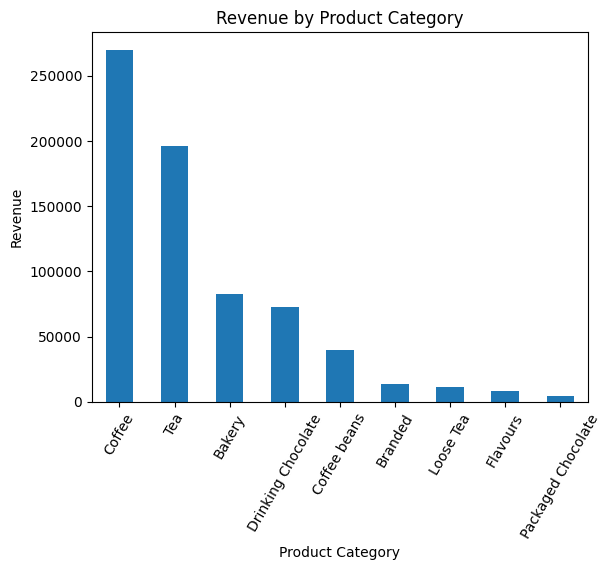

In [22]:
# revenue by product category

rev_category = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

plt.figure
rev_category.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=60)
plt.show()

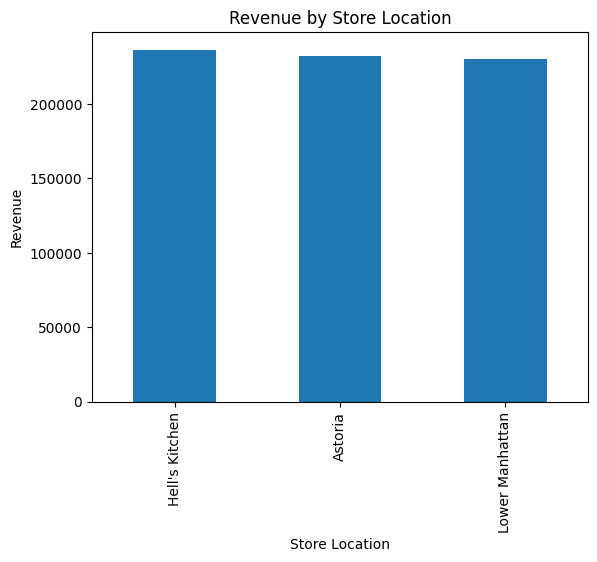

In [23]:
#  Revenue by Store Location

rev_location = df.groupby("store_location")["revenue"].sum().sort_values(ascending=False)
plt.figure()
rev_location.plot(kind="bar")
plt.title("Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Revenue")
plt.show()

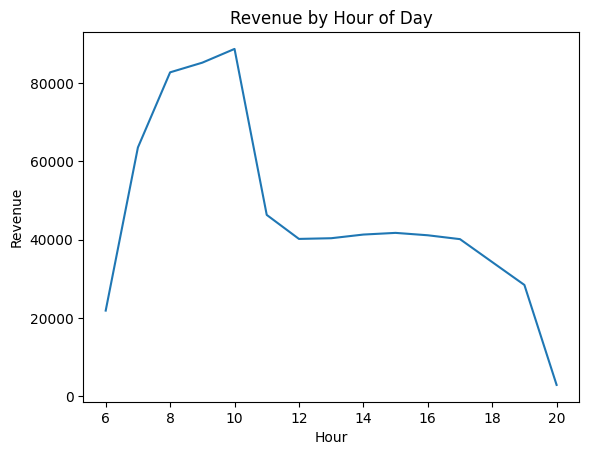

In [24]:
#  Revenue by Hour of Day

rev_hour = df.groupby("hour")["revenue"].sum()
plt.figure()
rev_hour.plot()
plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

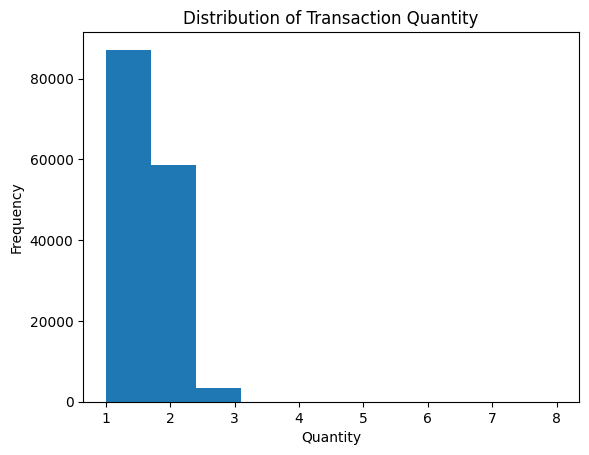

In [25]:
#  Distribution of Transaction Quantity

plt.figure()
df["transaction_qty"].plot(kind="hist", bins=10)
plt.title("Distribution of Transaction Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()


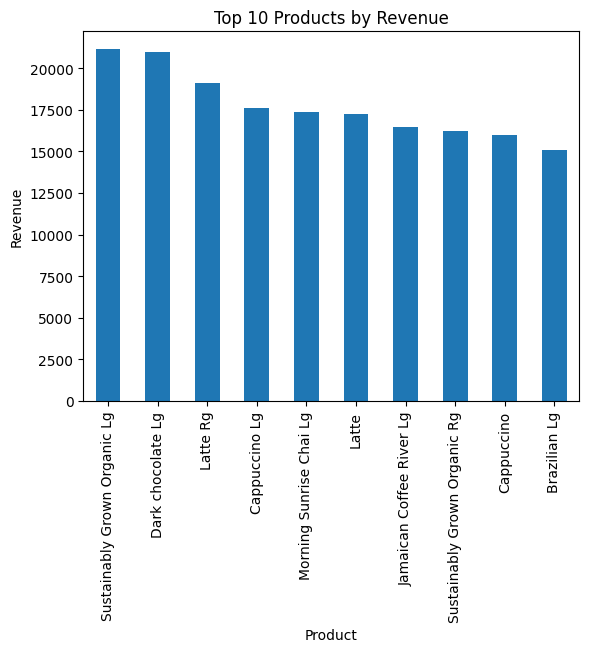

In [26]:
# Top 10 Products by Revenue

top_products = df.groupby("product_detail")["revenue"].sum().sort_values(ascending=False).head(10)
plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [27]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,hour,date,day_of_week,revenue,lag_1,lag_24,lag_168,roll_3,roll_7
0,1,2025,2026-02-05 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,2026-02-05,3,6.0,0.0,0.0,0.0,0.000000,0.0
1,2,2025,2026-02-05 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,2026-02-05,3,6.2,6.0,0.0,0.0,0.000000,0.0
2,3,2025,2026-02-05 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,2026-02-05,3,9.0,6.2,0.0,0.0,7.066667,0.0
3,4,2025,2026-02-05 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,2026-02-05,3,2.0,9.0,0.0,0.0,5.733333,0.0
4,5,2025,2026-02-05 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,2026-02-05,3,6.2,2.0,0.0,0.0,5.733333,0.0


In [28]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
oh = OneHotEncoder()

In [29]:
df["product_type"] = le.fit_transform(df["product_type"])
df["product_detail"] = le.fit_transform(df["product_detail"])


In [30]:
raw_df = df.copy()

In [31]:
split = raw_df.drop(columns=['transaction_id', 'transaction_time','date', 'day_of_week','revenue'])

In [32]:
X = split
y = raw_df['revenue']

# Categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()

#  Numerical columns
num_cols = X.select_dtypes(exclude='object').columns.tolist()

#  ColumnTransformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

#  Transform
X_processed = preprocessor.fit_transform(X)

In [33]:
X_processed

array([[0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 7.06666667,
        0.        ],
       ...,
       [1.        , 0.        , 0.        , ..., 3.5       , 4.66666667,
        4.64285714],
       [1.        , 0.        , 0.        , ..., 5.        , 4.25      ,
        4.67857143],
       [1.        , 0.        , 0.        , ..., 4.5       , 2.78333333,
        4.40714286]])

In [34]:
y = np.log1p(df["revenue"])

In [35]:
# train test split(time based)

train_size = int(len(X_processed) * 0.8)

X_train = X_processed[:train_size]
X_test  = X_processed[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [37]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
lr = LinearRegression()

In [38]:
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

LinearRegression()

In [39]:
# prediction
rf_pred = rf.predict(X_test)

lr_pred = lr.predict(X_test)

In [40]:
mask = y_test != 0

# evaluation (pipeline module)
results = pd.DataFrame({"Model": ["Random Forest", "Linear Regression"],
"RMSE": [np.sqrt(mean_squared_error(y_test, rf_pred)),
         np.sqrt(mean_squared_error(y_test, lr_pred))
],
"mse": [mean_squared_error(y_test, rf_pred),
        mean_squared_error(y_test, lr_pred)
],
"R2": [r2_score(y_test, rf_pred),
       r2_score(y_test, lr_pred)
],
"MAPE":[mean_absolute_percentage_error(y_test[mask],rf_pred[mask]),
        mean_absolute_percentage_error(y_test[mask],lr_pred[mask])
]
})

In [41]:
# comparison model
results

,Model,RMSE,mse,R2,MAPE
0,Random Forest,0.131922,0.017403,0.905696,0.067314
1,Linear Regression,0.113934,0.012981,0.929660,0.052826


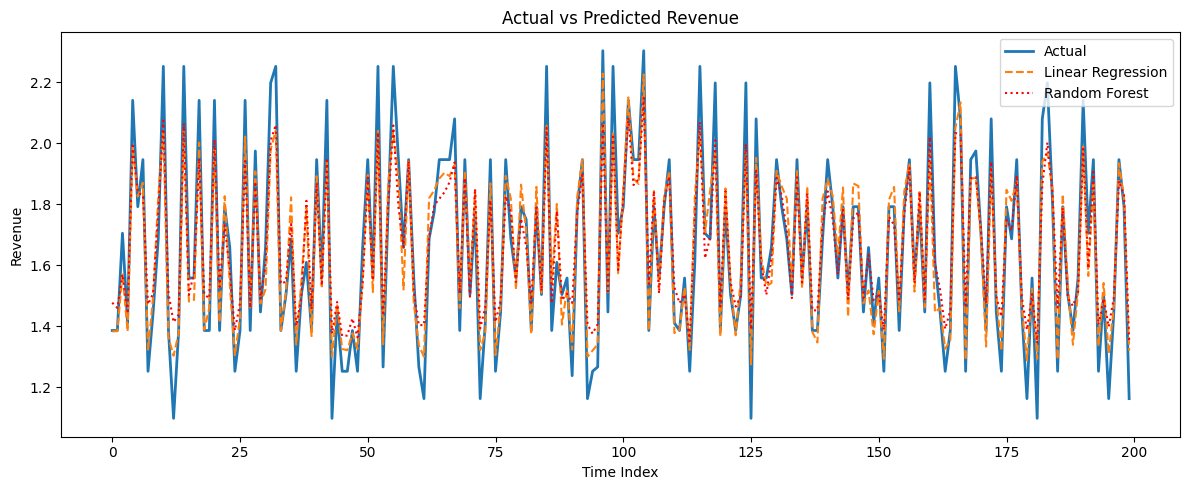

In [42]:
n= 200

plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:n], label="Actual", linewidth=2)
plt.plot(lr_pred[:n], label="Linear Regression", linestyle="--")
plt.plot(rf_pred[:n], label="Random Forest", linestyle=":",color="red")

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Time Index")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# prediction interval(for linear regression)

residuals_lr = y_test - lr_pred
sigma_lr = np.std(residuals_lr)
print(f"Standard Deviation of Residuals (Linear Regression): {sigma_lr}")

Standard Deviation of Residuals (Linear Regression): 0.11392923991550559


In [44]:
z = 1.96  # 95% confidence
lower_bound = lr_pred - z * sigma_lr
upper_bound = lr_pred + z * sigma_lr

In [45]:
# best case or worst case demand scenario

best_case = lr_pred + 2* sigma_lr
worst_case =lr_pred - 2* sigma_lr

In [46]:
# sensitivity to demand peek

spike_factor = 1.3 # 30% spike
y_spike = y_test * spike_factor

In [47]:
sensitivity = np.mean(np.abs(y_spike - lr_pred))
sensitivity

np.float64(0.4914612129514048)

In [48]:
spike_threshold = np.percentile(y_test, 90)

actual_spikes = y_test >= spike_threshold
predicted_spikes = lr_pred >= spike_threshold

spike_detection_rate = (
    (actual_spikes & predicted_spikes).sum() /
    actual_spikes.sum()
) * 100

spike_detection_rate

np.float64(56.914762957504294)

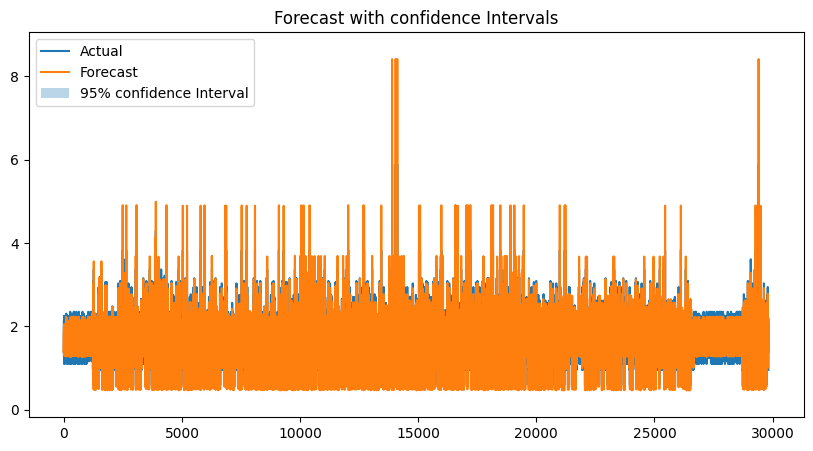

In [49]:
#  confidence interval Visualization

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(lr_pred, label="Forecast")
plt.fill_between(
    range(len(lr_pred)),
    lower_bound,
    upper_bound,
    alpha=0.3,
    label="95% confidence Interval"
)
plt.legend()
plt.title("Forecast with confidence Intervals")
plt.show()

In [50]:
uncertainty_kpi = pd.DataFrame({
    "Metric": [
        "Residual Std Dev (Uncertainty)",
        "Avg Prediction Interval Width",
        "Spike Sensitivity",
        "Spike Detection Rate (%)"
    ],
    "Value_for_lin_reg": [
        sigma_lr,
        np.mean(upper_bound - lower_bound),
        sensitivity,
        spike_detection_rate
    ]
})

uncertainty_kpi

,Metric,Value_for_lin_reg
0,Residual Std Dev (Uncertainty),0.113929
1,Avg Prediction Interval Width,0.446603
2,Spike Sensitivity,0.491461
3,Spike Detection Rate (%),56.914763


In [51]:
# KPI INDICATORS

mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100
Mape = np.mean(np.abs((y_test - lr_pred) / y_test)) * 100
forecast_accuracy_rf = 100 - mape
forecast_accuracy_lr = 100 - Mape

print(f"Random Forest Forecast Accuracy: {forecast_accuracy_rf:.2f}%")
print(f"Linear Regression Forecast Accuracy: {forecast_accuracy_lr:.2f}%")

Random Forest Forecast Accuracy: 93.27%
Linear Regression Forecast Accuracy: 94.72%


In [84]:
from sklearn.metrics import recall_score, f1_score

threshold = np.percentile(y_train, 80)

actual_peaks = y_test >= threshold

if actual_peaks.sum() == 0:
    raise ValueError("No peak periods detected in test data. Adjust percentile.")

predicted_peaks_rf = rf_pred >= threshold
predicted_peaks_lr = lr_pred >= threshold

# Calculate peak capture rates(recall)

peak_capture_rate_rf = recall_score(actual_peaks, predicted_peaks_rf) * 100
peak_capture_rate_lr = recall_score(actual_peaks, predicted_peaks_lr) * 100

# f1 score (balance strike control)

f1_rf = f1_score(actual_peaks, predicted_peaks_rf)
f1_lr = f1_score(actual_peaks, predicted_peaks_lr)

print(f"Random Forest Peak Capture Rate: {peak_capture_rate_rf:.2f}%")
print(f"Linear Regression Peak Capture Rate: {peak_capture_rate_lr:.2f}%")

print(f"Random Forest F1 Score: {f1_rf:.4f}")
print(f"Linear Regression F1 Score: {f1_lr:.4f}")

Random Forest Peak Capture Rate: 45.83%
Linear Regression Peak Capture Rate: 55.69%
Random Forest F1 Score: 0.6285
Linear Regression F1 Score: 0.7129


In [53]:
revenue_forecast_error_rf = np.mean(np.abs(y_test - rf_pred))
revenue_forecast_error_lr = np.mean(np.abs(y_test - lr_pred))

print(f"Random Forest Revenue Forecast Error: {revenue_forecast_error_rf}")
print(f"Linear Regression Revenue Forecast Error: {revenue_forecast_error_lr}")

Random Forest Revenue Forecast Error: 0.10227247185354889
Linear Regression Revenue Forecast Error: 0.08276278162071037


In [70]:
lead_time = 1

actual = y_test.values[lead_time:]
predicted_for_rf = rf_pred[:-lead_time]
prediction_for_lr = lr_pred[:-lead_time]



In [68]:
lead_time_BIAS_rf = np.mean(predicted_for_rf - actual)
lead_time_BIAS_lr = np.mean(prediction_for_lr - actual)

print(f"Random Forest Lead Time Bias: {lead_time_BIAS_rf}")
print(f"Linear Regression Lead Time Bias: {lead_time_BIAS_lr}")

Random Forest Lead Time Bias: -0.0019090603435267634
Linear Regression Lead Time Bias: 0.0010878353076374777


In [56]:
store_test = raw_df.loc[y_test.index, 'store_id'].reset_index(drop=True)


# Random Forest stability

stability_rf = pd.DataFrame({
    'store_id': store_test,
    'error': np.abs(y_test.values - rf_pred)
})

rf_store_stats = (
    stability_rf
    .groupby('store_id')['error']
    .agg(['count', 'std'])
)

# Only keep stores with >= 2 predictions
rf_store_stats = rf_store_stats[rf_store_stats['count'] >= 2]

store_forecast_stability_rf = rf_store_stats['std'].mean()


# Linear Regression stabilily

stability_lr = pd.DataFrame({
    'store_id': store_test,
    'error': np.abs(y_test.values - lr_pred)
})

lr_store_stats = (
    stability_lr
    .groupby('store_id')['error']
    .agg(['count', 'std'])
)

lr_store_stats = lr_store_stats[lr_store_stats['count'] >= 2]

store_forecast_stability_lr = lr_store_stats['std'].mean()


print(f"Random Forest Store Forecast Stability: {store_forecast_stability_rf:.4f}")
print(f"Linear Regression Store Forecast Stability: {store_forecast_stability_lr:.4f}")


Random Forest Store Forecast Stability: 0.0823
Linear Regression Store Forecast Stability: 0.0774


In [83]:
kpi_df_rf = pd.DataFrame({
    "KPI": [
        "Forecast Accuracy (%)",
        "Peak Demand Capture Rate (%)",
        "Revenue Forecast Error",
        "Lead Time BIAS ",
        "Store Forecast Stability"
    ],
    "Value": [
        forecast_accuracy_rf,
        peak_capture_rate_rf,
        revenue_forecast_error_rf,
        lead_time_BIAS_rf,
        store_forecast_stability_rf
    ]
})

kpi_df_lr = pd.DataFrame({
    "KPI": [
        "Forecast Accuracy (%)",
        "Peak Demand Capture Rate (%)",
        "Revenue Forecast Error",
        "Lead Time BIAS ",
        "Store Forecast Stability"
    ],
    "Value": [
        forecast_accuracy_lr,
        peak_capture_rate_lr,
        revenue_forecast_error_lr,
        lead_time_BIAS_lr,
        store_forecast_stability_lr
    ]
})



print(f"kpi_df_rf: {kpi_df_rf}")
print(f"kpi_df_lr: {kpi_df_lr}")

kpi_df_rf:                             KPI      Value
0         Forecast Accuracy (%)  93.268597
1  Peak Demand Capture Rate (%)  45.827423
2        Revenue Forecast Error   0.102272
3               Lead Time BIAS   -0.001909
4      Store Forecast Stability   0.082338
kpi_df_lr:                             KPI      Value
0         Forecast Accuracy (%)  94.717429
1  Peak Demand Capture Rate (%)  55.685579
2        Revenue Forecast Error   0.082763
3               Lead Time BIAS    0.001088
4      Store Forecast Stability   0.077409


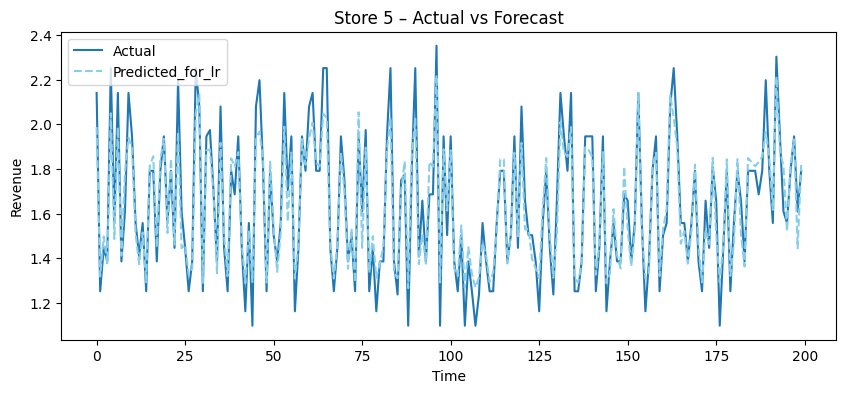

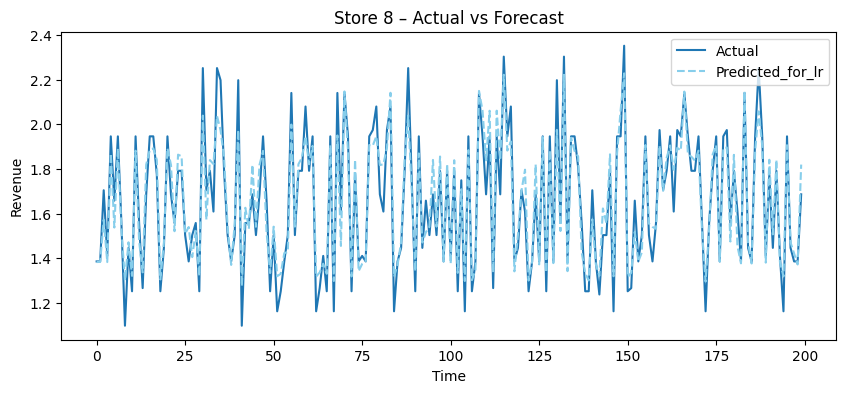

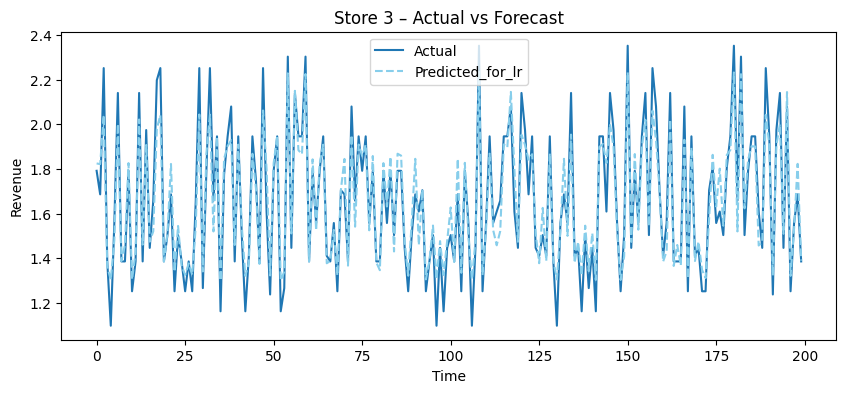

In [58]:
# store wize sales forecast

n=200

for store in raw_df["store_id"].unique():
    idx = raw_df["store_id"] == store

    plt.figure(figsize=(10,4))
    plt.plot(y_test[idx.iloc[train_size:]].values[:n], label="Actual")
    plt.plot(lr_pred[idx.iloc[train_size:]][:n], label="Predicted_for_lr",linestyle="--",color='skyblue')
    plt.title(f"Store {store} – Actual vs Forecast")
    plt.xlabel("Time")
    plt.ylabel("Revenue")
    plt.legend()
    plt.show()

In [59]:
raw_df['datetime'] = pd.to_datetime(raw_df['transaction_time'])

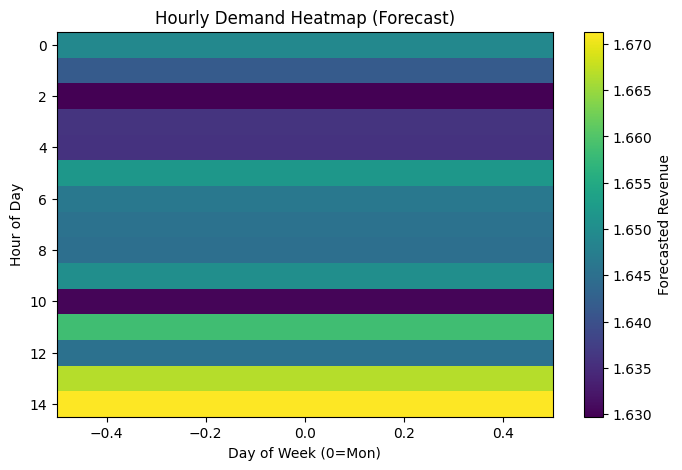

In [60]:
# hourly demand heatmap
heatmap_df = pd.DataFrame({
    "hour": raw_df.loc[train_size:, "hour"],
    "day": raw_df.loc[train_size:, "datetime"].dt.dayofweek,
    "forecast": lr_pred
})

pivot = heatmap_df.pivot_table(
    values="forecast",
    index="hour",
    columns="day",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Forecasted Revenue")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Hour of Day")
plt.title("Hourly Demand Heatmap (Forecast)")
plt.show()

In [61]:
# store selector

import ipywidgets as widgets
from IPython.display import display

store_selector = widgets.Dropdown(
    options=raw_df["store_id"].unique(),
    description="Store:",
    value=raw_df["store_id"].unique()[0]
)

display(store_selector)



Dropdown(description='Store:', options=(np.int64(5), np.int64(8), np.int64(3)), value=np.int64(5))

In [62]:
def plot_store_forecast(store_id):
    store_data = raw_df[raw_df["store_id"] == store_id]

    plt.figure(figsize=(10,4))
    plt.plot(store_data["revenue"].values[:n], label="Actual")
    plt.title(f"Store {store_id} – Revenue")
    plt.legend()
    plt.show()

widgets.interact(plot_store_forecast, store_id=store_selector)


interactive(children=(Dropdown(description='Store:', options=(np.int64(5), np.int64(8), np.int64(3)), value=np…

<function __main__.plot_store_forecast(store_id)>

In [63]:
# forecast horizon slizer

horizon_slider = widgets.IntSlider(
    value=12,
    min=1,
    max=48,
    step=1,
    description="Forecast Hours:"
)

display(horizon_slider)

IntSlider(value=12, description='Forecast Hours:', max=48, min=1)

In [64]:
def forecast_with_horizon(horizon):
    plt.figure(figsize=(10,4))
    plt.plot(lr_pred[:horizon], label="Forecast")
    plt.title(f"Forecast for Next {horizon} Hours")
    plt.legend()
    plt.show()

widgets.interact(forecast_with_horizon, horizon=horizon_slider)


interactive(children=(IntSlider(value=12, description='Forecast Hours:', max=48, min=1), Output()), _dom_class…

<function __main__.forecast_with_horizon(horizon)>

In [65]:
# revenue vs Quantity toggle
metric_toggle = widgets.ToggleButtons(
    options=["Revenue", "Quantity"],
    description="Metric:"
)

display(metric_toggle)


ToggleButtons(description='Metric:', options=('Revenue', 'Quantity'), value='Revenue')

In [66]:
def plot_metric(metric):
    if metric == "Revenue":
        data = raw_df["revenue"]
        ylabel = "Revenue"
    else:
        data = raw_df["transaction_qty"]
        ylabel = "Quantity Sold"

    plt.figure(figsize=(10,4))
    plt.plot(data.values)
    plt.title(f"{metric} Trend")
    plt.ylabel(ylabel)
    plt.show()

widgets.interact(plot_metric, metric=metric_toggle)


interactive(children=(ToggleButtons(description='Metric:', options=('Revenue', 'Quantity'), value='Revenue'), …

<function __main__.plot_metric(metric)>